In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os
print(os.listdir())

['Customer_Segmentation_py.csv', 'Untitled.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb', 'Untitled3.ipynb', 'sqlite.ipynb', 'cpp-tiny-ray-tracer.ipynb', 'Intro.ipynb', 'Lorenz.ipynb', 'cpp.ipynb', 'r.ipynb', 'cpp-third-party-libs.ipynb']


In [3]:
df = pd.read_csv('Customer_Segmentation_py.csv')

In [4]:
df.head()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,26/11/2013,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,26/11/2015,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,23/03/2014,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,23/03/2016,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,15/05/2014,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418


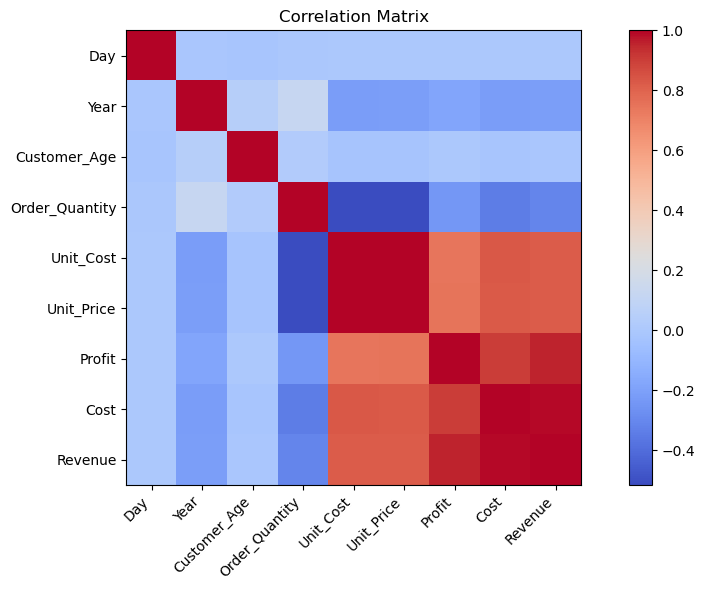

In [5]:
plt.figure(figsize=(10, 6))

correlation = df.select_dtypes(include='number').corr()

plt.imshow(correlation, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45, ha='right')
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### 1: Exploratory Data Analysis on Retail Sales Data


In [7]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (113036, 18)

Column names:
['Date', 'Day', 'Month', 'Year', 'Customer_Age', 'Age_Group', 'Customer_Gender', 'Country', 'State', 'Product_Category', 'Sub_Category', 'Product', 'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Profit', 'Cost', 'Revenue']

Data types:
Date                  str
Day                 int64
Month                 str
Year                int64
Customer_Age        int64
Age_Group             str
Customer_Gender       str
Country               str
State                 str
Product_Category      str
Sub_Category          str
Product               str
Order_Quantity      int64
Unit_Cost           int64
Unit_Price          int64
Profit              int64
Cost                int64
Revenue             int64
dtype: object

Missing values:
Date                0
Day                 0
Month               0
Year                0
Customer_Age        0
Age_Group           0
Customer_Gender     0
Country             0
State               0
Product_Category    0


### Observation

The analysis reveals increasing revenue, strong demand for Bikes, and a core customer base of ages 25–64. These insights can support better marketing, inventory, and sales strategies.


## 2. Descriptive Statistics

Descriptive statistics are used to summarize the numerical characteristics of the retail sales dataset. Mean, median, mode, and standard deviation are calculated to understand the central tendency and variability of the numerical variables.

In [8]:
# Select numerical columns
numerical_columns = df.select_dtypes(include='number').columns

# Calculate descriptive statistics
descriptive_stats = pd.DataFrame({
    'Mean': df[numerical_columns].mean(),
    'Median': df[numerical_columns].median(),
    'Mode': df[numerical_columns].mode().iloc[0],
    'Standard Deviation': df[numerical_columns].std()
})

descriptive_stats

,Mean,Median,Mode,Standard Deviation
Day,15.665753,16.0,24.0,8.781567
Year,2014.401739,2014.0,2014.0,1.272510
Customer_Age,35.919212,35.0,31.0,11.021936
Order_Quantity,11.901660,10.0,1.0,9.561857
Unit_Cost,267.296366,9.0,2.0,549.835483
Unit_Price,452.938427,24.0,5.0,922.071219
Profit,285.051665,101.0,3.0,453.887443
Cost,469.318695,108.0,1252.0,884.866118
Revenue,754.370360,223.0,35.0,1309.094674


### Observation

The descriptive statistics provide an overview of the distribution and variability of the numerical variables. The mean and median help identify the central values, while the mode represents the most frequently occurring value. Standard deviation indicates how widely the observations vary around their respective means. Differences between the mean and median may indicate skewness in variables such as revenue, profit, or order quantity.

## 3. Time Series Analysis

Time series analysis is performed to identify changes and patterns in sales over time. Monthly and quarterly revenue trends are analyzed using line charts to understand periods of higher and lower sales performance.

In [9]:
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Check the result
df['Date'].head()

<ipython-input-9-cf1491a194af>:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


0   2013-11-26
1   2015-11-26
2   2014-03-23
3   2016-03-23
4   2014-05-15
Name: Date, dtype: datetime64[us]

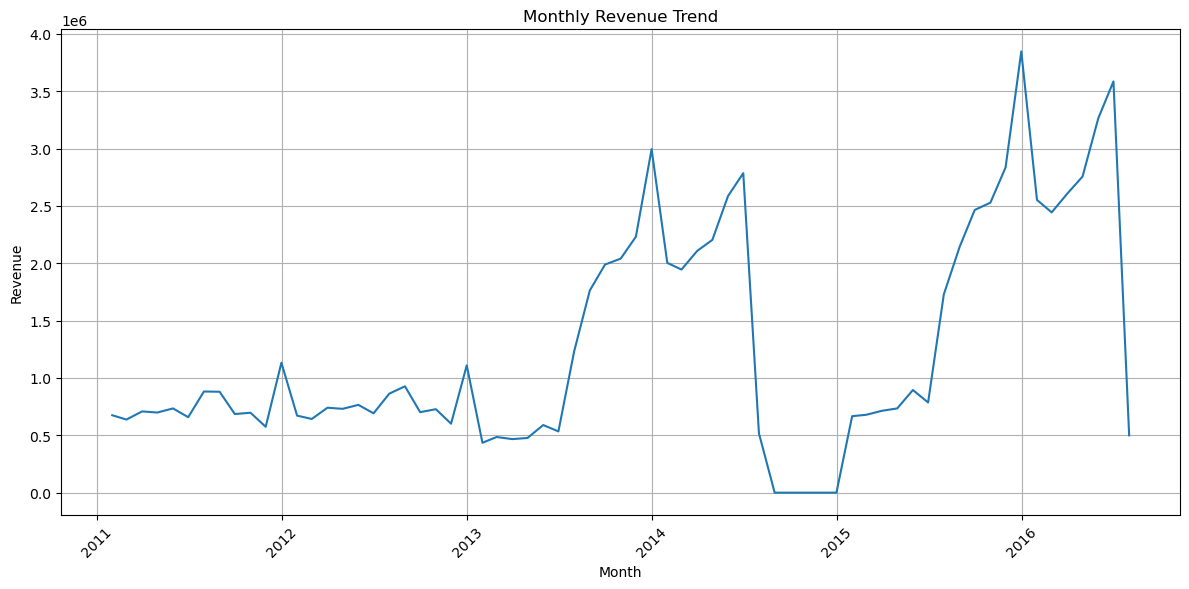

In [10]:
# Calculate monthly revenue
monthly_sales = df.resample('ME', on='Date')['Revenue'].sum()

# Plot monthly sales trend
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation

- The highest revenue was recorded in early 2016, at approximately 3.5 million.
- The lowest revenue was recorded in late 2014, when it dropped to almost zero.
- Revenue remained relatively stable from 2011 to 2013, followed by a significant increase during 2014.
- After a sharp decline in late 2014, revenue gradually increased throughout 2015.
- There are noticeable peaks and drops, especially during 2014 and 2016.
- Overall, the revenue shows an increasing trend over the years, despite some fluctuations.

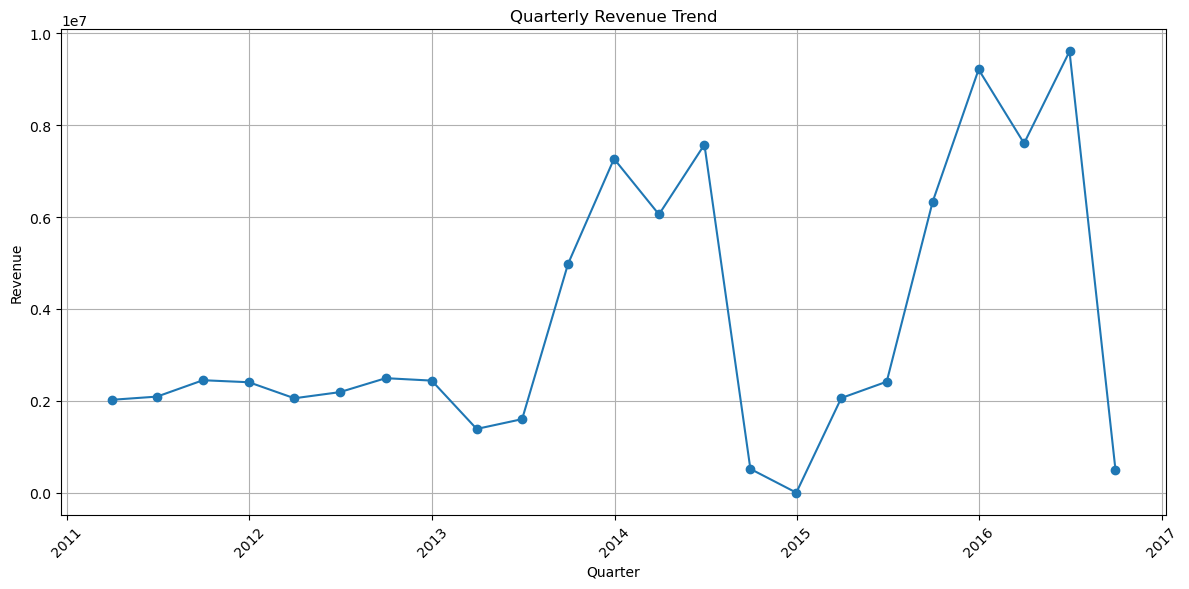

In [11]:
# Calculate quarterly revenue
quarterly_sales = df.resample('QE', on='Date')['Revenue'].sum()

# Plot quarterly sales trend
plt.figure(figsize=(12, 6))
plt.plot(quarterly_sales.index, quarterly_sales.values, marker='o')

plt.title('Quarterly Revenue Trend')
plt.xlabel('Quarter')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation

* The highest quarterly revenue was recorded in 2016, reaching approximately 9.5 million.
* The lowest quarterly revenue occurred around early 2015, at approximately 0.4 million.
* Revenue remained relatively stable from 2011 to 2013, with minor fluctuations.
* A significant increase in revenue was observed during late 2013 and 2014.
* Revenue experienced a sharp decline toward the end of 2014, followed by a gradual recovery during 2015.
* Revenue increased substantially again during 2016, indicating an overall upward trend despite periodic fluctuations.


## 4. Customer Demographics Analysis

Customer demographics are analyzed to understand the age distribution and gender composition of the customer base. This can help identify the primary customer segments and support targeted marketing strategies.

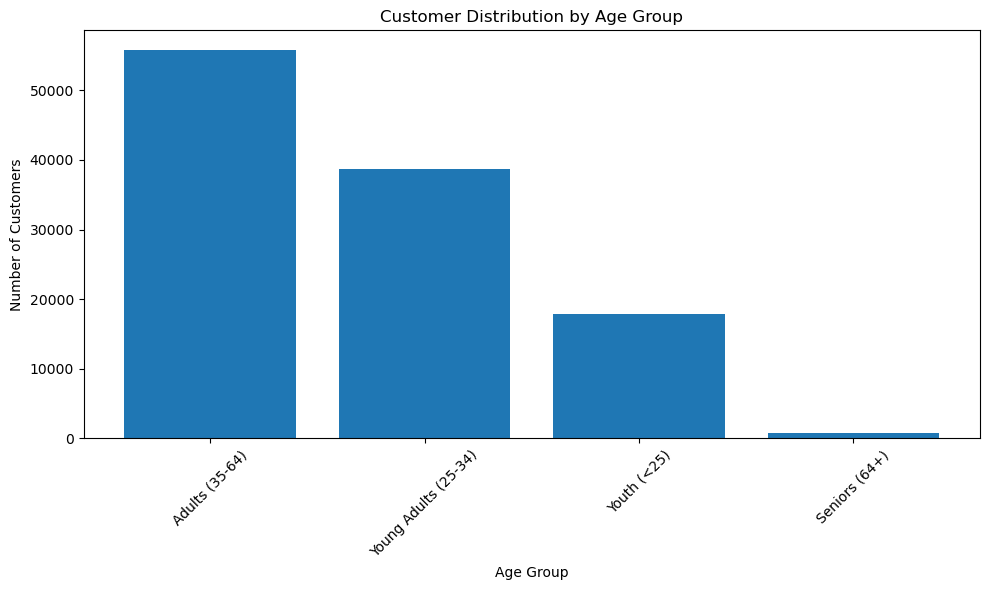

In [12]:
# Count customers in each age group
age_group_counts = df['Age_Group'].value_counts()

# Plot age group distribution
plt.figure(figsize=(10, 6))
plt.bar(age_group_counts.index, age_group_counts.values)

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

* The Adults (35–64) group is the largest customer segment, with more than 50,000 customers.
* Young Adults (25–34) form the second-largest segment, with nearly 40,000 customers.
* The Youth (<25) segment accounts for fewer than 20,000 customers.
* Seniors (64+) represent a very small proportion of the overall customer base.
* Overall, customers between 25 and 64 years form the core customer base and represent the strongest target segment for marketing and sales activities.


Customer_Gender
M    58312
F    54724
Name: count, dtype: int64


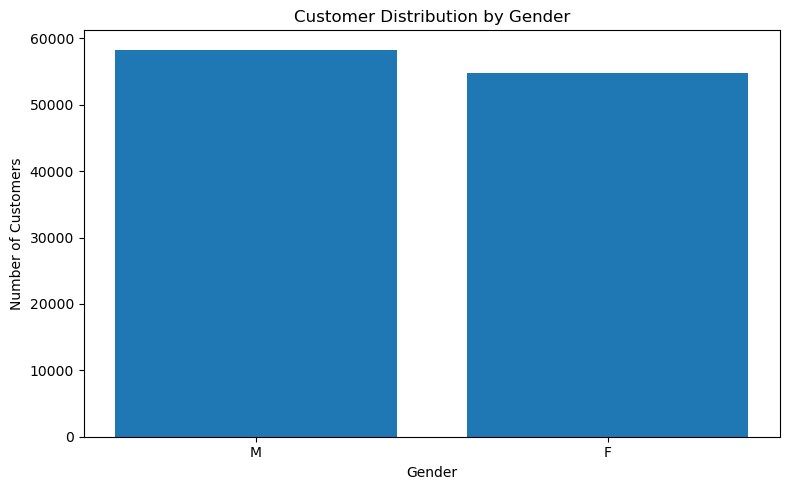

In [13]:
# Count customers by gender
gender_counts = df['Customer_Gender'].value_counts()

# Display the counts
print(gender_counts)

# Plot gender breakdown
plt.figure(figsize=(8, 5))
plt.bar(gender_counts.index, gender_counts.values)

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

### Observation

* Male customers account for 58,312 records, while female customers account for 54,724 records.
* The distribution is relatively balanced, with males representing approximately 51.6% and females approximately 48.4% of the dataset.
* Neither gender represents a dominant majority, indicating that the retail business has broad appeal across genders.
* Marketing campaigns and product strategies can therefore be designed with a balanced and inclusive approach, rather than focusing heavily on one gender.


## 5. Product Analysis

Product-level analysis is performed to identify the best-selling products and understand how revenue is distributed across different product categories.

In [14]:
# Calculate total quantity sold for each product
top_products = (
    df.groupby('Product')['Order_Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product
Water Bottle - 30 oz.      164086
Patch Kit/8 Patches        157583
Mountain Tire Tube         102792
AWC Logo Cap                67316
Sport-100 Helmet, Red       63663
Road Tire Tube              62296
Fender Set - Mountain       62118
Sport-100 Helmet, Black     62105
Touring Tire Tube           56802
Sport-100 Helmet, Blue      55895
Name: Order_Quantity, dtype: int64


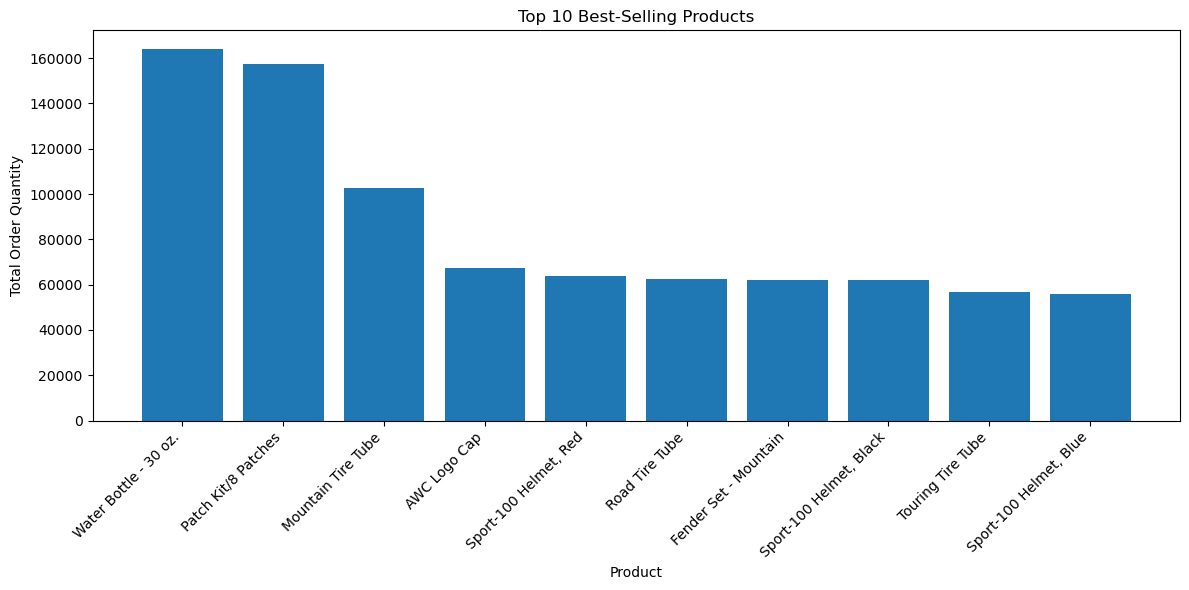

In [15]:
plt.figure(figsize=(12, 6))

plt.bar(top_products.index, top_products.values)

plt.title('Top 10 Best-Selling Products')
plt.xlabel('Product')
plt.ylabel('Total Order Quantity')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Observation

* Water Bottle – 30 oz. and Patch Kit/8 Patches are the strongest-selling products, with both exceeding 150,000 units in total order quantity.
* The top-selling products are primarily bicycle accessories and maintenance items, such as water bottles, patch kits, tire tubes, and helmets, rather than complete bicycles.
* Different variants of helmets and tire tubes also show consistently strong demand, indicating that customers purchase these products regularly across multiple variants.
* The high demand for accessories suggests that these products are important contributors to overall sales volume.

### Business Insight

* High-volume accessories can be promoted as bundle items, cross-sell products, or checkout recommendations alongside bicycle purchases.
* Frequently purchased maintenance products should receive appropriate inventory priority to reduce the risk of stockouts during periods of high demand.


In [16]:
# Calculate total revenue by product category
category_revenue = (
    df.groupby('Product_Category')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

print(category_revenue)

Product_Category
Bikes          61782134
Accessories    15117992
Clothing        8370882
Name: Revenue, dtype: int64


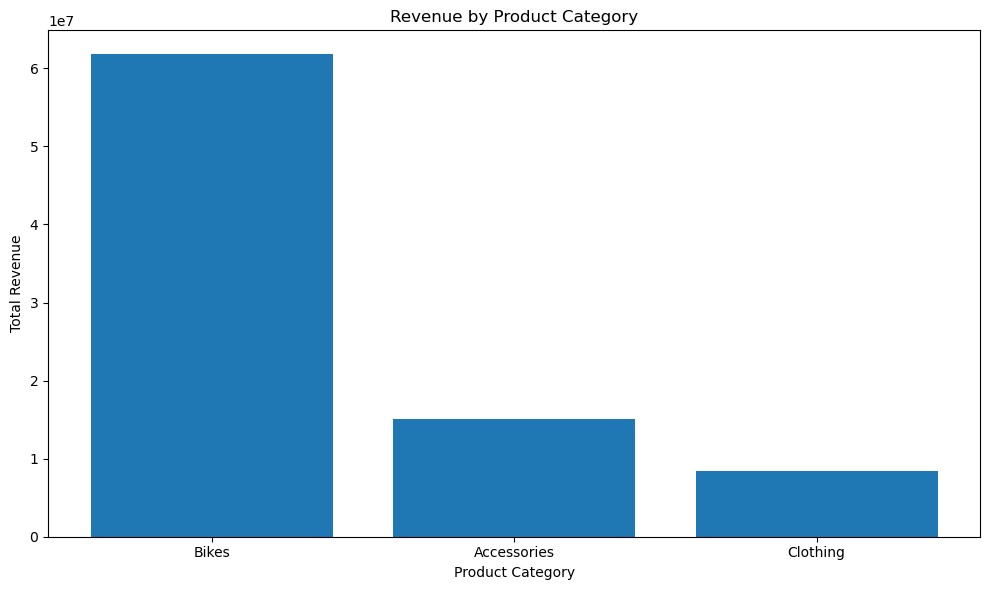

In [17]:
plt.figure(figsize=(10, 6))

plt.bar(category_revenue.index, category_revenue.values)

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')

plt.tight_layout()
plt.show()

### Observation

* Bikes generate the vast majority of total revenue, at approximately 61.78 million, making them the primary revenue-generating category.
* Accessories are the second-largest revenue contributor at approximately 15.12 million, followed by Clothing at approximately 8.37 million.
* There is a clear contrast between sales volume and revenue contribution. Low-cost products such as water bottles and patch kits have very high order quantities, while higher-priced bicycle products generate substantially more revenue.
* This indicates that Bikes are the core financial engine of the business, while Accessories and Clothing provide important supporting revenue streams.

### Business Insight

* The business should continue prioritizing Bikes, as they are the strongest contributor to overall revenue.
* Accessories and Clothing can be used for cross-selling and bundle offers, especially when customers purchase a bicycle.
* Combining high-value bicycle purchases with relevant accessories or apparel could increase the average order value and revenue from secondary categories.


### 6. Heatmap: correlation matrix between numerical variables


In [18]:
# Select numerical columns
numerical_data = df.select_dtypes(include='number')

# Calculate correlation matrix
correlation_matrix = numerical_data.corr()

correlation_matrix

,Day,Year,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
Day,1.000000,-0.007635,-0.014296,-0.002412,0.003133,0.003207,0.004623,0.003329,0.003853
Year,-0.007635,1.000000,0.040994,0.123169,-0.217575,-0.213673,-0.181525,-0.215604,-0.208673
Customer_Age,-0.014296,0.040994,1.000000,0.026887,-0.021374,-0.020262,0.004319,-0.016013,-0.009326
Order_Quantity,-0.002412,0.123169,0.026887,1.000000,-0.515835,-0.515925,-0.238863,-0.340382,-0.312895
Unit_Cost,0.003133,-0.217575,-0.021374,-0.515835,1.000000,0.997894,0.741020,0.829869,0.817865
Unit_Price,0.003207,-0.213673,-0.020262,-0.515925,0.997894,1.000000,0.749870,0.826301,0.818522
Profit,0.004623,-0.181525,0.004319,-0.238863,0.741020,0.749870,1.000000,0.902233,0.956572
Cost,0.003329,-0.215604,-0.016013,-0.340382,0.829869,0.826301,0.902233,1.000000,0.988758
Revenue,0.003853,-0.208673,-0.009326,-0.312895,0.817865,0.818522,0.956572,0.988758,1.000000


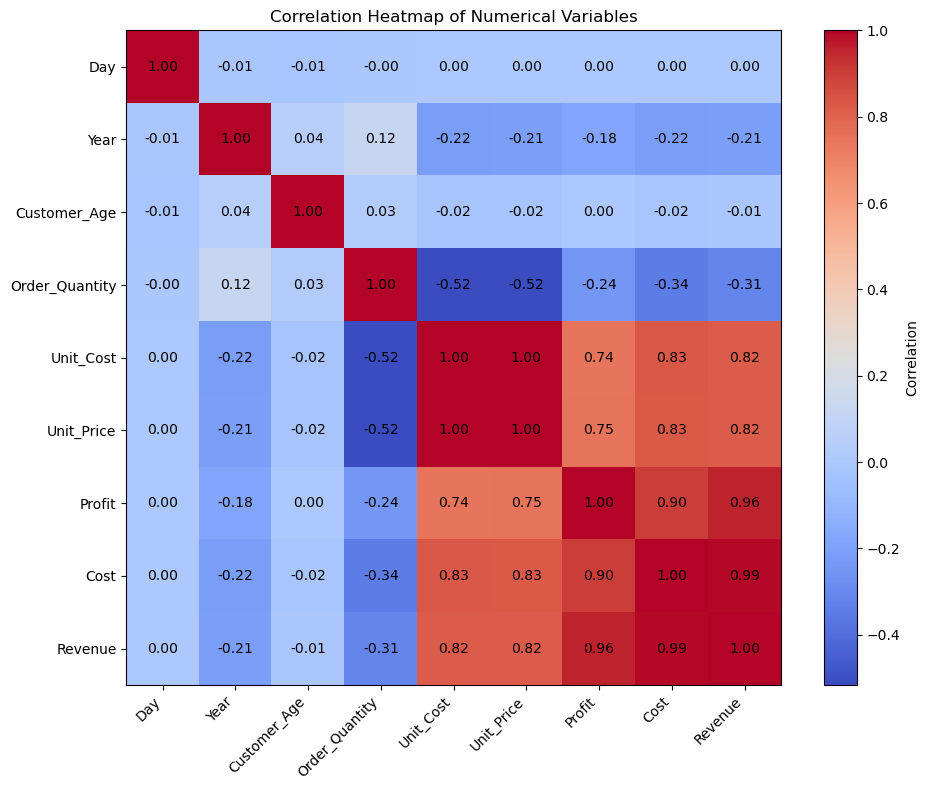

In [19]:
plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='none')

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title('Correlation Heatmap of Numerical Variables')

# Display correlation values inside the heatmap
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j, i,
            f'{correlation_matrix.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )

plt.tight_layout()
plt.show()

### Observation

* Unit Cost and Unit Price have an extremely strong positive correlation of approximately 0.998, indicating that products with higher costs generally have higher selling prices.
* Revenue and Profit also show a very strong positive correlation of approximately 0.957, suggesting that higher-revenue transactions generally contribute to higher profits.
* Cost and Profit have a strong positive correlation of approximately 0.902, while Cost and Revenue have a strong positive correlation of approximately 0.956.
* Order Quantity has a moderate negative correlation with Unit Cost and Unit Price, at approximately -0.516, indicating that lower-priced products tend to be purchased in larger quantities.
* Customer Age has very weak correlations with most numerical variables, suggesting that age alone does not strongly determine order quantity, price, cost, revenue, or profit in this dataset.
* Day also has very weak correlations with the other numerical variables, indicating that the day of the month has little linear relationship with sales-related measures.

### Business Insight

The heatmap highlights an important volume-versus-value relationship: lower-priced products tend to be purchased in larger quantities, while higher-priced products contribute more strongly to revenue and profit. This supports the earlier product analysis, where accessories generated high order volumes while Bikes generated the majority of total revenue.


## 7. Calculate profit by age group

In [20]:
profit_by_age = (
    df.groupby('Age_Group')['Profit']
    .sum()
    .sort_values(ascending=False)
)

print(profit_by_age)

Age_Group
Adults (35-64)          16321582
Young Adults (25-34)    11386761
Youth (<25)              4374592
Seniors (64+)             138165
Name: Profit, dtype: int64


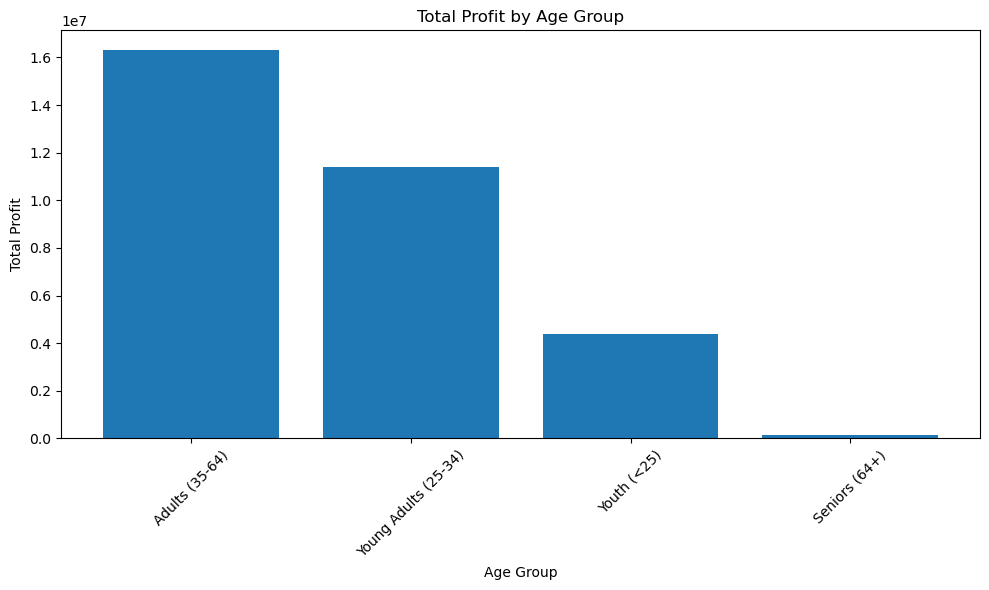

In [21]:
plt.figure(figsize=(10, 6))

plt.bar(profit_by_age.index, profit_by_age.values)

plt.title('Total Profit by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Profit')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

* Adults (35–64) generate the highest total profit at approximately 16.32 million.
* Young Adults (25–34) are the second-highest profit-generating group, contributing approximately 11.39 million.
* Youth (<25) contribute approximately 4.37 million in total profit.
* Seniors (64+) generate the lowest profit, at approximately 0.14 million.
* Overall, customers aged 25–64 are the most valuable customer segments, generating the majority of total profit.

### Business Insight

The business should prioritize customers aged 25–64 through targeted marketing, loyalty programs, and personalized offers, as these groups contribute substantially more profit than younger and senior customers.


### 9. Conclusion


### Conclusion

The exploratory data analysis provided useful insights into sales trends, customer behaviour, product performance, and profitability.

### Recommendations

1. Focus on Bikes as the primary revenue driver and maintain sufficient inventory to meet demand.

2. Use accessories and clothing as cross-selling opportunities by offering bundles and recommendations with bike purchases.

3. Target customers aged 25–64 with personalized promotions and loyalty programs, as they generate the majority of profit.

4. Maintain adequate stock of high-volume accessories such as water bottles, patch kits, and tire tubes to avoid stockouts.
